## Observation matrix

### Sky model 

The sky signal observed by the detectors can be written as

$$
\mathbf{d} = \mathbf{P}\,\mathbf{m}_{\rm in} + \mathbf{n},
$$

where $\mathbf{P}$ is the pointing matrix, including all coordinate transformations
required to project the sky-stationary signal into the detector time-ordered data (TOD).

The ideal model of polarization measurement is

$$
d(t)
=
I(t)
+
\mathrm{Re}
\left\{
\left[Q(t)+iU(t)\right]
\exp\left[-4i\phi_{\rm HWP}(t)+2i\alpha_{\rm det}(t)\right]
\right\}
+
n(t).
$$

Equivalently, this can be written as

$$
d(t)
=
I(t)
+
Q(t)\cos\left(4\phi_{\rm HWP}(t)-2\alpha_{\rm det}(t)\right)
+
U(t)\sin\left(4\phi_{\rm HWP}(t)-2\alpha_{\rm det}(t)\right)
+
n(t).
$$

Defining the effective polarization angle as

$$
\psi(t)=2\phi_{\rm HWP}(t)-\alpha_{\rm det}(t),
$$

each time sample can be expressed as

$$
d(t)
=
\begin{pmatrix}
1 & \cos(2\psi(t)) & \sin(2\psi(t))
\end{pmatrix}
\begin{pmatrix}
I_p\\
Q_p\\
U_p
\end{pmatrix}
+n(t).
$$

For example, if we measure 5 time-ordered samples ($N_t=5$) while observing a
two-pixel sky ($N_p=2$), the measurement equation becomes

$$
\underbrace{
\begin{pmatrix}
d_1\\
d_2\\
d_3\\
d_4\\
d_5
\end{pmatrix}
}_{N_t \times 1}
=
\underbrace{
\begin{pmatrix}
1 & \cos(2\psi_1) & \sin(2\psi_1) & 0 & 0 & 0\\
0 & 0 & 0 & 1 & \cos(2\psi_2) & \sin(2\psi_2)\\
1 & \cos(2\psi_3) & \sin(2\psi_3) & 0 & 0 & 0\\
0 & 0 & 0 & 1 & \cos(2\psi_4) & \sin(2\psi_4)\\
1 & \cos(2\psi_5) & \sin(2\psi_5) & 0 & 0 & 0
\end{pmatrix}
}_{N_t \times 3N_p}
\underbrace{
\begin{pmatrix}
I_1\\
Q_1\\
U_1\\
I_2\\
Q_2\\
U_2
\end{pmatrix}
}_{3N_p \times 1}
+
\begin{pmatrix}
n_1\\
n_2\\
n_3\\
n_4\\
n_5
\end{pmatrix}.
$$

### Mapmaking

#### Binned mapmaking

The simplest mapmaking approach is **binned mapmaking**, where the map is
estimated by averaging all time-ordered samples that fall into each pixel:

$$
\mathbf{\hat m}
=
(\mathbf{P}^{T}\mathbf{P})^{-1}
\mathbf{P}^{T}\mathbf{d}.
$$

This estimator assumes uncorrelated and uniform white noise. Therefore, it
does not take into account correlations between different time samples.

---

#### Maximum likelihood mapmaking

The binned mapmaker is not optimal when the noise contains time-domain
correlations. To account for correlated noise, we introduce the noise covariance
matrix:

$$
\mathbf{N}
=
\langle \mathbf{n}\mathbf{n}^{T}\rangle .
$$

The maximum likelihood estimator is then obtained by minimizing

$$
\chi^2
=
(\mathbf{d}-\mathbf{P}\mathbf{m})^{T}
\mathbf{N}^{-1}
(\mathbf{d}-\mathbf{P}\mathbf{m}),
$$

which gives

$$
\mathbf{\hat m}
=
(\mathbf{P}^{T}\mathbf{N}^{-1}\mathbf{P})^{-1}
\mathbf{P}^{T}\mathbf{N}^{-1}\mathbf{d}.
$$

In many CMB experiments, the noise covariance is approximately stationary in
time. In this case, the covariance matrix has a Toeplitz structure:

$$
\mathbf{N}_{ij}
=
\langle n_i n_j\rangle
=
R(|i-j|),
$$

where $R$ is the noise autocorrelation function.

However, explicitly constructing and inverting the full correlated noise
covariance is computationally expensive for large TOD datasets.

---

#### Template mapmaking

An alternative approach is to model correlated noise components using a set of
templates and remove them during mapmaking. The timestream is written as

$$
\mathbf{d}
=
\mathbf{P}\mathbf{m}
+
\mathbf{T}\mathbf{x}
+
\mathbf{n}_{\rm white},
$$

where:

- $\mathbf{P}\mathbf{m}$ is the sky signal,
- $\mathbf{T}$ is a matrix containing noise templates,
- $\mathbf{x}$ is the amplitude of each template,
- $\mathbf{n}_{\rm white}$ is the remaining white noise.

The corresponding likelihood is

$$
\chi^2
=
(\mathbf{d}-\mathbf{P}\mathbf{m}-\mathbf{T}\mathbf{x})^T
\mathbf{N}_{\rm white}^{-1}
(\mathbf{d}-\mathbf{P}\mathbf{m}-\mathbf{T}\mathbf{x}).
$$

Solving simultaneously for the sky map and template amplitudes,

$$
\frac{\partial\chi^2}{\partial\mathbf{m}}=0,
\qquad
\frac{\partial\chi^2}{\partial\mathbf{x}}=0,
$$

leads to a map estimator equivalent to projecting out the template modes:

$$
\mathbf{\hat m}
=
(\mathbf{P}^{T}\mathbf{N}_{\rm white}^{-1}
\mathbf{D}_{T}
\mathbf{P})^{-1}
\mathbf{P}^{T}\mathbf{N}_{\rm white}^{-1}
\mathbf{D}_{T}
\mathbf{d},
$$

where the template deprojection operator is defined as

$$
\mathbf{D}_{T}
=
\mathbf{I}
-
\mathbf{T}
(\mathbf{T}^{T}\mathbf{N}_{\rm white}^{-1}\mathbf{T})^{-1}
\mathbf{T}^{T}
\mathbf{N}_{\rm white}^{-1}.
$$

This operator removes all components lying in the template subspace:

$$
\mathbf{D}_{T}\mathbf{T}=0.
$$

Therefore, template mapmaking avoids explicitly modeling the full correlated
noise covariance by transferring the correlated modes into a set of templates
that can be projected out during map reconstruction.

### Observation matrix

In practical mapmaking, the template filtering operator is usually applied
directly to the TOD before map reconstruction:

$$
\mathbf{d}_{\rm filt}
=
\mathbf{D}_{T}\mathbf{d}.
$$

Since the filtering operation acts on the time domain, it also affects the
sky signal contained in the TOD:

$$
\mathbf{d}_{\rm filt}
=
\mathbf{D}_{T}\mathbf{P}\mathbf{m}_{\rm in}
+
\mathbf{D}_{T}\mathbf{n}.
$$

The reconstructed map is therefore not exactly equal to the input sky map.
Instead, the mapmaking process can be described by an effective observation
matrix:

$$
\mathbf{m}_{\rm out}
=
\mathbf{O}\mathbf{m}_{\rm in},
$$

where $\mathbf{O}$ describes how the input sky signal is modified by the
time-domain processing and map reconstruction.

For the filtered binned mapmaker,

$$
\mathbf{O}
=
(\mathbf{P}^{T}\mathbf{N}_{\rm white}^{-1}\mathbf{P})^{-1}
\mathbf{P}^{T}\mathbf{N}_{\rm white}^{-1}
\mathbf{D}_{T}
\mathbf{P}.
$$

Ideally, the observation matrix should satisfy

$$
\mathbf{O}=\mathbf{I},
$$

meaning that the input sky signal is perfectly preserved. However, because
the template projection removes modes from the TOD,

$$
\mathbf{D}_{T}\neq\mathbf{I},
$$

and some sky modes can be partially filtered out:

$$
\mathbf{O}\neq\mathbf{I}.
$$

This loss of signal is usually characterized in harmonic space through a
transfer function. Assuming statistical isotropy, the effect of the
observation matrix can be approximated as a multipole-dependent response:

$$
a_{\ell m}^{\rm out}
\simeq
\sqrt{T_\ell}\,
a_{\ell m}^{\rm in},
$$

where $T_\ell$ is the power-spectrum transfer function describing the fraction
of input power recovered after the complete time-domain filtering and
mapmaking pipeline. Therefore,

$$
C_\ell^{\rm out}
=
T_\ell C_\ell^{\rm in}.
$$

## Training data

There are two models
- ObsMat:
$$
\mathbf{m} = \mathbf{M}(\mathbf{O \tilde Y B s} + \mathbf{n})
$$
where $\mathbf{M}$ is the mask, $\mathbf{O}$ is the observation matrix, $\mathbf{\tilde Y}$ is the spherial harmonic transform, $\mathbf{B}$ is the beam, $\mathbf{s}$ is a set of B-mode spherical harmonic coefficients (CMB + dust + sync)
- Transfer function
$$
\mathbf{m} = \mathbf{M}(\mathbf{\tilde Y B T s} + \mathbf{n})
$$
where $\mathbf{T}$ is the transfer function

In [1]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
from sbi_bmode import so_utils, sim_utils, script_utils
from sbi_bmode import spectra_utils
import yaml

In [3]:
with open('config_transfer.yaml') as f:
    config = yaml.safe_load(f)

data_dict, fixed_params_dict, params_dict, observation_dict, transfer_dict = script_utils.parse_config(config)
true_params = script_utils.get_true_params(params_dict)

In [4]:
specdir = '/u/bing/sbi_bmode/data'
figdir = "/u/bing/sbi_bmode/binh/figures"
maskfile = "/u/bing/sbi_bmode/data/obsmat_planck70_apod_C2_3deg.fits"

sim_obsmat = sim_utils.CMBSimulator(
    specdir,
    data_dict,
    fixed_params_dict,
    observation_dict=observation_dict,
    mask_file=maskfile
)

Using observation type: obsmat
[obsmat] Reusing ObsMat f090 for all frequencies
[f090 GHz] loading obsmat: sobs_RC1.r01_SAT1_mission_f090_4way_coadd_sky_obsmat_healpix.npz
[rank N/A] ObsMat loaded for bands: ['f090']
Loading mask from /u/bing/sbi_bmode/data/obsmat_planck70_apod_C2_3deg.fits


In [10]:
def plot_component_spectra(
    sim,
    r_tensor,
    A_lens,

    A_d_BB,
    alpha_d_BB,
    beta_dust,
    amp_beta_dust,
    gamma_beta_dust,

    A_s_BB=None,
    alpha_s_BB=None,
    beta_sync=None,
    amp_beta_sync=None,
    gamma_beta_sync=None,

    rho_ds=None,
    freq_idx=0,
    apply_beam=True,
    dl=True,
):
    """
    Plot the unbinned input CMB / dust / sync / dust-sync-cross BB
    spectra for one frequency channel of an already-constructed
    CMBSimulator `sim`.
    """
    ell = np.arange(sim.lmax + 1)
    fstr = sim.freq_strings[freq_idx]
    freq = sim.freqs[freq_idx]

    # --- CMB ---
    cmb_cov = spectra_utils.get_combined_cmb_spectrum(
        r_tensor, A_lens, sim.cov_scalar_ell, sim.cov_tensor_ell
    )
    cmb_ee = np.asarray(cmb_cov[0, 0])
    cmb_bb = np.asarray(cmb_cov[1, 1])

    # --- Dust ---
    dust_cov = spectra_utils.get_dust_spectra(
        A_d_BB, alpha_d_BB, sim.lmax, sim.freqs, beta_dust,
        sim.temp_dust, sim.freq_pivot_dust,
    )
    dust_bb = np.asarray(dust_cov[freq_idx, freq_idx])

    # --- Sync ---
    sync_bb = None
    if A_s_BB is not None:
        sync_cov = spectra_utils.get_sync_spectra(
            A_s_BB, alpha_s_BB, sim.lmax, sim.freqs, beta_sync, sim.freq_pivot_sync,
        )
        sync_bb = np.asarray(sync_cov[freq_idx, freq_idx])

    # --- Dust x Sync cross term ---
    cross_bb = None
    if rho_ds is not None and A_s_BB is not None:
        cross_cov = spectra_utils.get_dust_sync_cross_spectra(
            rho_ds, A_d_BB, alpha_d_BB, A_s_BB, alpha_s_BB,
            sim.lmax, sim.freqs, beta_dust, sim.temp_dust, beta_sync,
            sim.freq_pivot_dust, sim.freq_pivot_sync,
        )
        cross_bb = np.asarray(cross_cov[freq_idx, freq_idx])

    if apply_beam:
        beam2 = sim.b_ells[freq_idx] ** 2
        cmb_ee, cmb_bb, dust_bb = cmb_ee * beam2, cmb_bb * beam2, dust_bb * beam2
        if sync_bb is not None:
            sync_bb = sync_bb * beam2
        if cross_bb is not None:
            cross_bb = cross_bb * beam2

    to_dl = lambda cl: ell * (ell + 1) / (2 * np.pi) * cl
    good = ell >= 2

    fig, ax = plt.subplots(figsize=(7, 5))
    for y, label, c in [
        (cmb_ee, "CMB EE", "C0"),
        (cmb_bb, f"CMB BB (r={r_tensor}, A_lens={A_lens})", "C1"),
        (dust_bb, f"Dust BB @ {fstr}", "C2"),
    ]:
        y_plot = to_dl(y) if dl else y
        ax.loglog(ell[good], y_plot[good], label=label, color=c)

    if sync_bb is not None:
        y_plot = to_dl(sync_bb) if dl else sync_bb
        ax.loglog(ell[good], y_plot[good], label=f"Sync BB @ {fstr}", color="C3")

    if cross_bb is not None:
        y_plot = to_dl(cross_bb) if dl else cross_bb
        ax.loglog(ell[good], y_plot[good], color="C4",
                   label=f"Dust×Sync BB @ {fstr} (rho={rho_ds})")

    ax.set_xlabel(r"$\ell$")
    ax.set_ylabel(r"$D_\ell\ [\mu K^2]$" if dl else r"$C_\ell\ [\mu K^2]$")
    ax.set_title(f"Input component spectra @ {fstr} ({freq/1e9:.0f} GHz)")
    ax.legend(fontsize=8)
    ax.grid(True, which="both", alpha=0.3)
    fig.tight_layout()
    return fig, ax

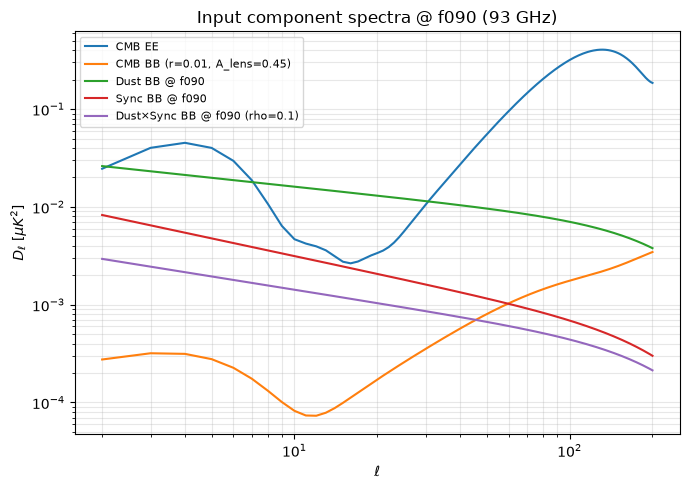

In [11]:
fig, ax = plot_component_spectra(sim_obsmat, **true_params)

In [5]:
out_obsmat = sim_obsmat.draw_data(
    **true_params,
    seed=0,
    return_maps=True,
)

: 

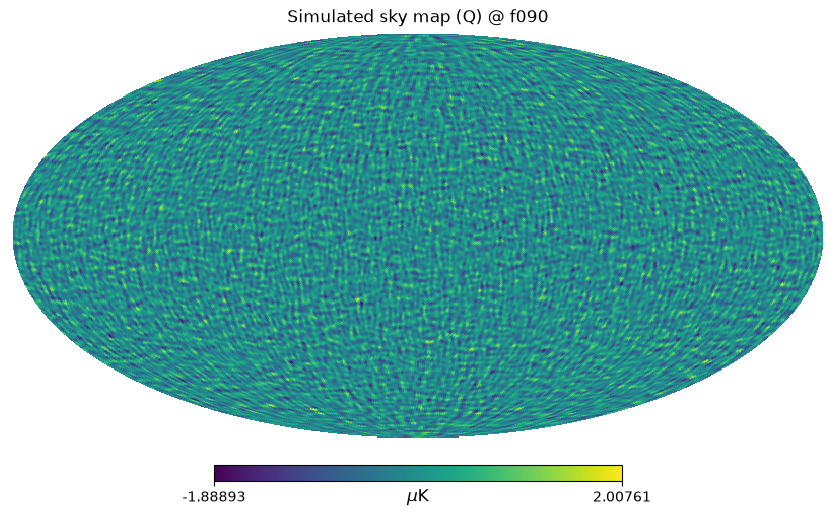

In [14]:
hp.mollview(out_obsmat['sky_map'][0, 0, 0], title="Simulated sky map (Q) @ f090", unit=r"$\mu$K")

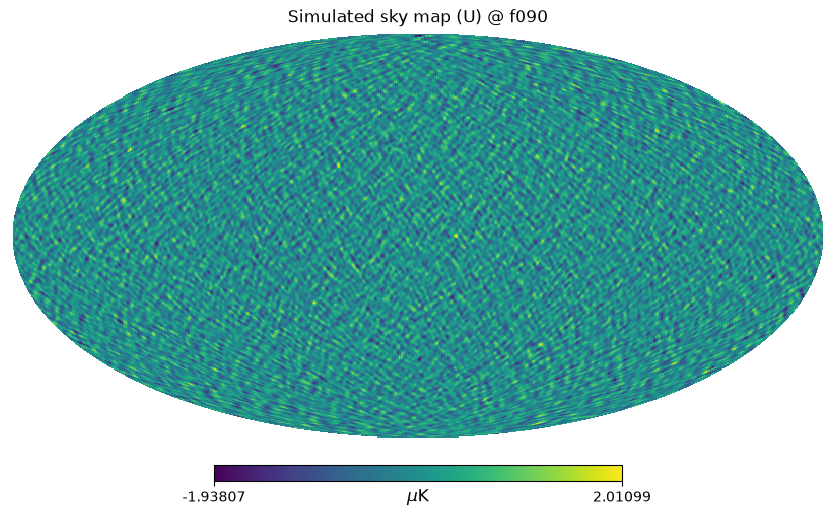

In [16]:
hp.mollview(out_obsmat['sky_map'][0, 0, 1], title="Simulated sky map (U) @ f090", unit=r"$\mu$K")

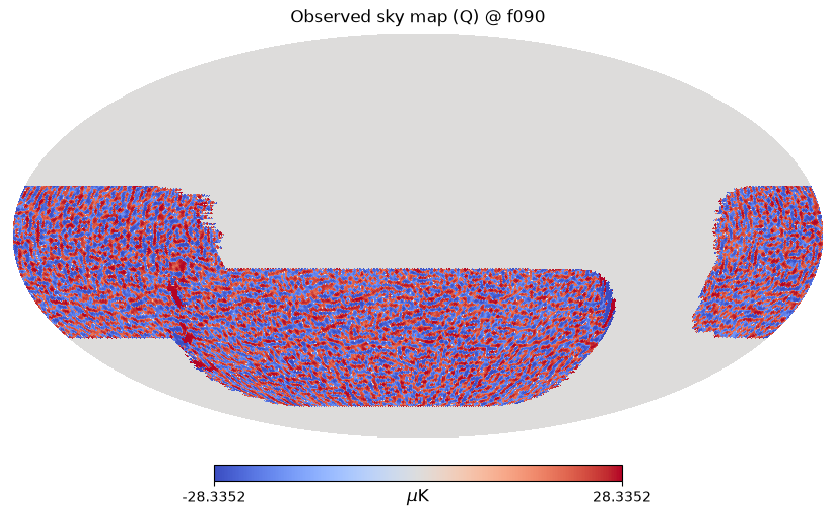

In [23]:
hp.mollview(
    out_obsmat['obs_map'][0,0,0],
    min=-np.nanmax(np.abs(out_obsmat['obs_map'][0,0,0])),
    max= np.nanmax(np.abs(out_obsmat['obs_map'][0,0,0])),
    cmap="coolwarm",
    unit=r"$\mu\mathrm{K}$",
    norm="hist",
    title="Observed sky map (Q) @ f090"
)

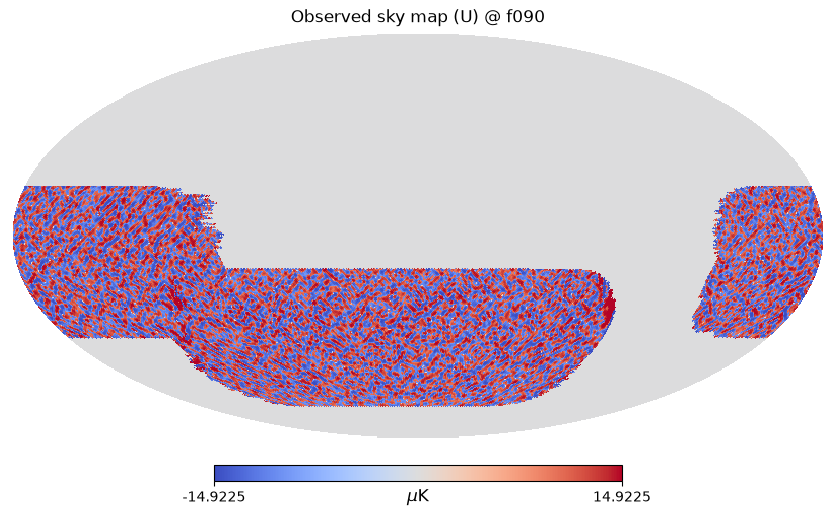

In [ ]:
hp.mollview(
    out_obsmat['obs_map'][0,0,1],
    min=-np.nanmax(np.abs(out_obsmat['obs_map'][0,0,1])),
    max= np.nanmax(np.abs(out_obsmat['obs_map'][0,0,1])),
    cmap="coolwarm",
    unit=r"$\mu\mathrm{K}$",
    norm="hist",
    title="Observed sky map (U) @ f090"
)

## Load Observation Matrix

In [4]:
obsmat = so_utils.load_obs_matrix(config['data']['freq_strings'], config['observation']['obsmat_dir'])

[f090 GHz] loading obsmat: sobs_RC1.r01_SAT1_mission_f090_4way_coadd_sky_obsmat_healpix.npz


In [13]:
obs_map = out_obsmat["obs_map"][0, 0, 0]

npix = obs_map.size

# find a valid pixel
valid_pix = np.where(obs_map != 0)[0]
pix = valid_pix[0]

# create input Q/U map
test_sky_map_in = np.zeros((1, 1, 2, npix), dtype=np.float32)

# put delta = 1 in Q at one pixel
test_sky_map_in[0, 0, 0, pix] = 1.0

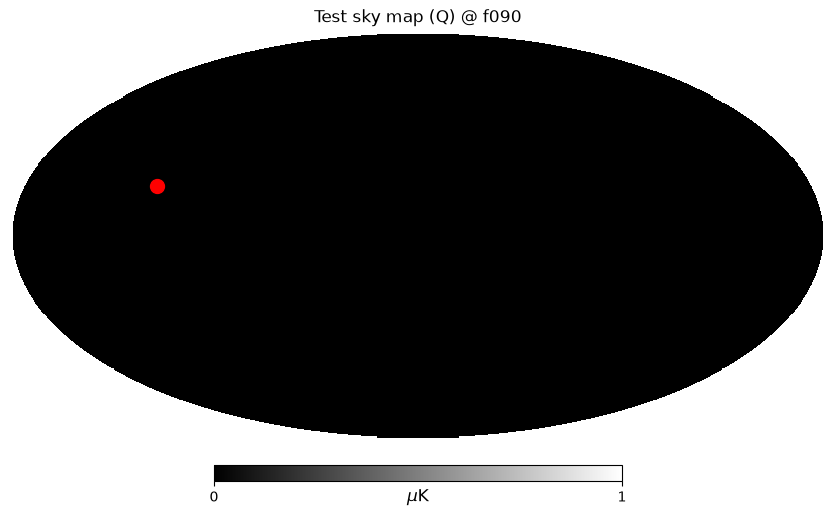

In [ ]:
# plot the map
hp.mollview(
    test_sky_map_in[0, 0, 0],
    title="Test sky map (Q) @ f090",
    unit=r"$\mu$K",
    min=0,
    max=1,
    cmap="gray"
)

# convert pixel index to angular coordinates
theta, phi = hp.pix2ang(hp.get_nside(test_sky_map_in), pix)

# highlight it
hp.projscatter(
    theta,
    phi,
    lonlat=False,
    marker="o",
    color="red",
    s=100
)

plt.show()

In [14]:
test_sky_map_out = sim_utils.apply_obsmatrix(
    test_sky_map_in,
    obsmat
)

[f090] applying observation matrix split 0


In [15]:
test_sky_map_out.shape
# (1, 1, 2, npix)

(1, 1, 2, 196608)

### MSS2

In [ ]:
so_utils.load_obs_matrix()

### MSS3